# Black Scholes Application and Extensions in Crypto

Deribit BTC USDC options from the `with_iv` parquets. The feed runs at roughly 100 ms and totals around 100 GB across 83 day partitions.

The structure is straightforward. Black Scholes is the benchmark — not because anyone believes it, but because every extension needs a transparent baseline to beat. The notebook then layers on local vol, Merton, Heston, and Bates in a daily walk-forward that mimics a production refit cadence: calibrate on the prior five days, price the next day unseen.

A note on data granularity. Intraday frequency adds noise without adding information for cross-sectional model comparison at this calibration budget. Each day is reduced to its densest intraday snapshot — the timestamp with the broadest liquid cross-section — before entering the panel.

## Black Scholes as the starting point

Under the risk-neutral measure, GBM for spot gives the familiar closed forms

$$C = S_0 N(d_1) - K e^{-rT} N(d_2)$$

$$P = K e^{-rT} N(-d_2) - S_0 N(-d_1)$$

$$d_1 = \frac{\ln(S_0/K) + (r + \frac12\sigma^2)T}{\sigma \sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

The model is misspecified by construction in crypto: the smile is large, the term structure of vol is steep, and realized vol is non-Gaussian. None of that is a reason to skip it. Black-Scholes prices are the market's quoting convention and its implied vol is the coordinate system every extension maps back to.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from utils.option_pricing import (
    aggregate_surface_quotes,
    attach_black_scholes_metrics,
    available_deribit_days,
    build_surface_grid,
    dupire_local_vol,
    extract_daily_snapshots,
    filter_liquid_quotes,
    implied_volatility,
    inspect_deribit_schema,
    load_deribit_day,
    pick_dense_snapshot,
    price_local_vol_mc,
    summarize_daily_atm_term_structure,
    top_symbols_for_day,
    walk_forward_model_grid_search,
)

sns.set_theme(style="whitegrid")
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 10

ROOT = Path("/Volumes/EXTREME_SSD/data/deribit_option/tmp1/parquets/with_iv")
UNDERLYING = "BTC_USDC-PERPETUAL"
RATE = 0.0
SCHEMA_SIDE = "CALL"
TOP_SYMBOL_COUNT = 30
PILOT_DAY_LIMIT = 30
PILOT_MIN_QUOTES = 4
COLUMNS = [
    "datetime",
    "symbol",
    "underlying",
    "side",
    "strike_price",
    "expiry_datetime",
    "mid_price",
    "bid_price",
    "ask_price",
    "und_mid",
    "ttm_days",
    "ttm",
    "log_moneyness",
    "rel_spread",
    "ts",
    "dt_day",
    "iv_mid",
    "delta",
]

In [2]:
days = available_deribit_days(ROOT, underlying=UNDERLYING)
latest_day = days[-1]

schema_info = inspect_deribit_schema(
    ROOT,
    underlying=UNDERLYING,
    dt_day=latest_day,
    side=SCHEMA_SIDE,
)
top_symbol_counts, TOP_SYMBOLS = top_symbols_for_day(
    ROOT,
    underlying=UNDERLYING,
    dt_day=latest_day,
    top_n=TOP_SYMBOL_COUNT,
)

print(f"Available day partitions: {len(days)}")
print(f"First day: {days[0]}")
print(f"Latest day: {latest_day}")
print(f"Schema side inspected: {SCHEMA_SIDE}")
print(f"Rows in inspected parquet file: {schema_info['rows']:,}")
print(f"Pilot top symbol count: {TOP_SYMBOL_COUNT}")

display(schema_info["columns"])

display(top_symbol_counts)

day_df = load_deribit_day(
    ROOT,
    underlying=UNDERLYING,
    dt_day=latest_day,
    columns=COLUMNS,
    symbols=TOP_SYMBOLS,
 )

print(f"Pilot rows on latest day: {len(day_df):,}")
print(f"Pilot unique symbols: {day_df['symbol'].nunique()}")
print(f"Pilot unique timestamps: {day_df['ts'].nunique():,}")
display(day_df.head())

Available day partitions: 83
First day: 20470
Latest day: 20572
Schema side inspected: CALL
Rows in inspected parquet file: 2,021,897
Pilot top symbol count: 30


,column,dtype
0,datetime,double
1,symbol,large_string
2,underlying,large_string
3,side,large_string
4,strike_price,double
5,expiry_datetime,double
6,last_price,double
7,bid_price,double
8,ask_price,double
9,bid_qty,double


,symbol,side,quote_count
0,btc_usdc-1may26-75500-p,PUT,44887
1,btc_usdc-1may26-76000-p,PUT,42295
2,btc_usdc-1may26-75000-p,PUT,40512
3,btc_usdc-2may26-75000-p,PUT,39008
4,btc_usdc-2may26-78000-c,CALL,38484
5,btc_usdc-1may26-76500-p,PUT,38465
6,btc_usdc-2may26-75500-p,PUT,38040
7,btc_usdc-1may26-77500-c,CALL,37827
8,btc_usdc-1may26-78000-c,CALL,37161
9,btc_usdc-2may26-74500-p,PUT,37066


Pilot rows on latest day: 1,055,702
Pilot unique symbols: 30
Pilot unique timestamps: 78,649


,datetime,symbol,underlying,side,strike_price,expiry_datetime,mid_price,bid_price,ask_price,und_mid,ttm_days,ttm,log_moneyness,rel_spread,ts,dt_day,iv_mid,delta
0,1.777421e+09,btc_usdc-8may26-79000-c,BTC_USDC-PERPETUAL,CALL,79000.0,1.778227e+09,727.5,685.0,770.0,76324.75,9.333314,0.025571,0.034451,0.116838,1777420801,20572,0.353157,0.280350
1,1.777421e+09,btc_usdc-1may26-77500-c,BTC_USDC-PERPETUAL,CALL,77500.0,1.777622e+09,460.0,435.0,485.0,76324.75,2.333314,0.006393,0.015281,0.108696,1777420801,20572,0.379977,0.312852
2,1.777421e+09,btc_usdc-1may26-77000-c,BTC_USDC-PERPETUAL,CALL,77000.0,1.777622e+09,642.5,620.0,665.0,76324.75,2.333314,0.006393,0.008808,0.070039,1777420801,20572,0.385189,0.393348
3,1.777421e+09,btc_usdc-1may26-76500-c,BTC_USDC-PERPETUAL,CALL,76500.0,1.777622e+09,885.0,800.0,970.0,76324.75,2.333314,0.006393,0.002293,0.192090,1777420801,20572,0.398038,0.477610
4,1.777421e+09,btc_usdc-2may26-77000-c,BTC_USDC-PERPETUAL,CALL,77000.0,1.777709e+09,800.0,725.0,875.0,76324.75,3.333311,0.009132,0.008808,0.187500,1777420801,20572,0.378081,0.410709


Top 30 symbols by quote count on the latest day. At this stage the objective is a liquid, tight-spread surface for diagnostic work — not breadth. Stale books and wide relative spreads contaminate IV calibration and show up as spurious model error. The full symbol universe is restored when we move to the walk-forward panel.

## From tape to tradable cross-section

At 100 ms, the tape is dominated by repeated quotes for the same contract. Loading the full day to price a cross-section is wasteful and unnecessary. Instead, the schema is inspected cheaply, the densest intraday timestamp is identified on a lightweight first pass, and only that snapshot is pulled into memory. Filters then drop quotes with relative spread above 20%, TTM below one day, and mid price below $5 — the standard liquidity screen before any IV-based work.

In [3]:
target_ts, snapshot = pick_dense_snapshot(day_df, min_quotes=PILOT_MIN_QUOTES)
liquid_snapshot = filter_liquid_quotes(
    snapshot,
    max_rel_spread=0.20,
    min_ttm=1.0 / 365.0,
    min_price=5.0,
 )
enriched_snapshot = attach_black_scholes_metrics(liquid_snapshot, rate=RATE)

recovered_iv = implied_volatility(
    price=enriched_snapshot["mid_price"].to_numpy(),
    spot=enriched_snapshot["und_mid"].to_numpy(),
    strike=enriched_snapshot["strike_price"].to_numpy(),
    ttm=enriched_snapshot["ttm"].to_numpy(),
    rate=RATE,
    option_type=enriched_snapshot["side"].to_numpy(),
    initial_vol=np.clip(enriched_snapshot["iv_mid"].fillna(0.5).to_numpy(), 0.05, 1.5),
)
enriched_snapshot["iv_roundtrip"] = recovered_iv
enriched_snapshot["iv_roundtrip_error"] = enriched_snapshot["iv_roundtrip"] - enriched_snapshot["iv_mid"]

snapshot_summary = pd.Series(
    {
        "dense_timestamp": int(target_ts),
        "pilot_symbol_count": len(TOP_SYMBOLS),
        "quote_count_before_filter": len(snapshot),
        "quote_count_after_filter": len(enriched_snapshot),
        "unique_expiries": enriched_snapshot["expiry_datetime"].nunique(),
        "strike_min": enriched_snapshot["strike_price"].min(),
        "strike_max": enriched_snapshot["strike_price"].max(),
        "median_iv": enriched_snapshot["iv_mid"].median(),
        "median_abs_bs_error": enriched_snapshot["bs_error"].abs().median(),
        "max_abs_iv_roundtrip_error": enriched_snapshot["iv_roundtrip_error"].abs().max(),
    }
)

display(snapshot_summary.to_frame("value"))
display(
    enriched_snapshot[
        [
            "symbol",
            "side",
            "strike_price",
            "ttm_days",
            "und_mid",
            "mid_price",
            "iv_mid",
            "iv_roundtrip",
            "bs_price",
            "bs_error",
            "bs_delta",
            "bs_gamma",
            "bs_vega",
        ]
    ]
    .sort_values(["ttm_days", "strike_price"])
    .head(12)
)

,value
dense_timestamp,1.777433e+09
pilot_symbol_count,3.000000e+01
quote_count_before_filter,4.700000e+01
quote_count_after_filter,4.700000e+01
unique_expiries,4.000000e+00
strike_min,7.100000e+04
strike_max,8.100000e+04
median_iv,3.861801e-01
median_abs_bs_error,0.000000e+00
max_abs_iv_roundtrip_error,0.000000e+00


,symbol,side,strike_price,ttm_days,und_mid,mid_price,iv_mid,iv_roundtrip,bs_price,bs_error,bs_delta,bs_gamma,bs_vega
525958,btc_usdc-30apr26-76500-p,PUT,76500.0,1.194506,76808.25,540.0,0.390473,0.390473,540.0,0.000000e+00,-0.424187,0.000228,1721.186904
533390,btc_usdc-30apr26-76000-p,PUT,76000.0,1.194514,76808.25,365.0,0.398994,0.398994,365.0,7.275958e-12,-0.317437,0.000203,1566.024054
605154,btc_usdc-30apr26-76500-p,PUT,76500.0,1.194514,76808.25,542.5,0.391924,0.391924,542.5,0.000000e+00,-0.424433,0.000227,1721.397630
525956,btc_usdc-1may26-75000-p,PUT,75000.0,2.194506,76808.25,335.0,0.420194,0.420194,335.0,0.000000e+00,-0.227381,0.000121,1796.832147
605156,btc_usdc-1may26-75500-p,PUT,75500.0,2.194506,76808.25,452.5,0.411547,0.411547,452.5,3.637979e-12,-0.289684,0.000140,2037.604927
518580,btc_usdc-1may26-76000-p,PUT,76000.0,2.194506,76808.25,602.5,0.403058,0.403058,602.5,3.637979e-12,-0.361627,0.000156,2231.569126
98224,btc_usdc-1may26-76500-c,CALL,76500.0,2.194506,76808.25,1060.0,0.378499,0.378499,1060.0,7.275958e-12,0.560286,0.000175,2348.784542
511133,btc_usdc-1may26-76500-p,PUT,76500.0,2.194506,76808.25,807.5,0.402222,0.402222,807.5,7.275958e-12,-0.442540,0.000165,2351.277254
104730,btc_usdc-1may26-77000-c,CALL,77000.0,2.194506,76808.25,802.5,0.376279,0.376279,802.5,0.000000e+00,0.471751,0.000178,2370.005147
525957,btc_usdc-1may26-77000-p,PUT,77000.0,2.194506,76808.25,1040.0,0.395579,0.395579,1040.0,0.000000e+00,-0.526292,0.000169,2370.802631


The IV round-trip confirms that the Newton solver and the BS pricer are mutually consistent. Any discrepancy here is a numerical issue in the inversion, not a market anomaly — worth catching before it propagates into calibration residuals downstream.

## Greeks

$$\Delta = N(d_1), \qquad \Gamma = \frac{\phi(d_1)}{S_0 \sigma \sqrt{T}}, \qquad \mathcal{V} = S_0 \phi(d_1)\sqrt{T}$$

Theta and rho are computed in the utility layer. In crypto the gamma and vega profiles matter more than in equity: short-dated BTC options can be deeply convex, the gamma concentration near expiry is substantial, and vega exposure is large because realized vol is high. These Greeks are the relevant risk coordinates regardless of which pricing model sits underneath.

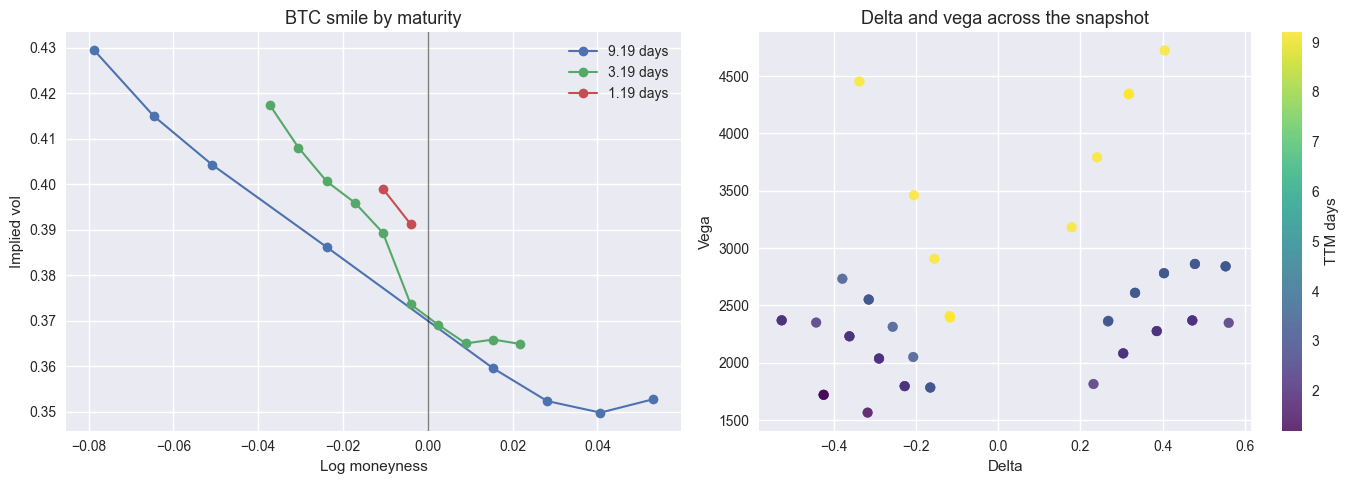

In [4]:
available_maturities = np.sort(enriched_snapshot["ttm_days"].unique())
target_maturities = [7.0, 30.0, 60.0]
selected_maturities = []
minimum_gap_days = 2.0

for target in target_maturities:
    ranked = sorted(available_maturities, key=lambda value: abs(value - target))
    chosen = next(
        (
            value
            for value in ranked
            if all(abs(value - existing) >= minimum_gap_days for existing in selected_maturities)
        ),
        None,
    )
    if chosen is not None:
        selected_maturities.append(chosen)

if not selected_maturities:
    selected_maturities = [available_maturities[len(available_maturities) // 2]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for maturity in selected_maturities:
    subset = enriched_snapshot.loc[np.isclose(enriched_snapshot["ttm_days"], maturity)].copy()
    smile = (
        subset.groupby("log_moneyness", as_index=False)
        .agg(
            iv_mid=("iv_mid", "median"),
            ttm_days=("ttm_days", "median"),
        )
        .sort_values("log_moneyness")
    )
    axes[0].plot(
        smile["log_moneyness"],
        smile["iv_mid"],
        marker="o",
        linewidth=1.5,
        label=f"{smile['ttm_days'].iloc[0]:.2f} days",
    )

axes[0].axvline(0.0, color="black", linewidth=1, alpha=0.5)
axes[0].set_title("BTC smile by maturity")
axes[0].set_xlabel("Log moneyness")
axes[0].set_ylabel("Implied vol")
axes[0].legend()

scatter = axes[1].scatter(
    enriched_snapshot["bs_delta"],
    enriched_snapshot["bs_vega"],
    c=enriched_snapshot["ttm_days"],
    cmap="viridis",
    alpha=0.8,
)
axes[1].set_title("Delta and vega across the snapshot")
axes[1].set_xlabel("Delta")
axes[1].set_ylabel("Vega")
fig.colorbar(scatter, ax=axes[1], label="TTM days")
plt.tight_layout()
plt.show()

The smile chart shows where the flat-vol assumption is most wrong. The delta-vega scatter shows where that misspecification has the largest P&L consequence: high vega and rapidly changing delta in the same region means that hedging errors compound quickly under a misspecified model.

## History panel

All 83 day partitions, no symbol filter. One dense intraday snapshot per day. The objective is a time series of ATM implied vol and underlying level that is representative of the full sample period rather than the most recent regime. This panel drives the walk-forward comparison and the realized vol calculation.

In [5]:
DAY_LIMIT = None
FULL_SAMPLE_DAY_COUNT = len(days)
FULL_SAMPLE_SYMBOLS = None

daily_snapshot_panel = extract_daily_snapshots(
    ROOT,
    underlying=UNDERLYING,
    day_limit=DAY_LIMIT,
    columns=COLUMNS,
    max_rel_spread=0.20,
    min_quotes=PILOT_MIN_QUOTES,
    symbols=FULL_SAMPLE_SYMBOLS,
 )

atm_term = summarize_daily_atm_term_structure(daily_snapshot_panel)
atm_30d = (
    atm_term.assign(ttm_gap=(atm_term["ttm_days"] - 30.0).abs())
    .sort_values(["snapshot_day", "ttm_gap", "rel_spread"])
.groupby("snapshot_day")
    .head(1)
    .sort_values("snapshot_day")
)

underlying_daily = (
    daily_snapshot_panel.groupby("snapshot_day", as_index=True)["und_mid"]
    .median()
    .sort_index()
)
underlying_log_return = np.log(underlying_daily).diff()
realized_vol_window = max(5, min(21, len(underlying_daily) // 6))
realized_vol = underlying_log_return.rolling(
    realized_vol_window,
    min_periods=realized_vol_window,
).std() * np.sqrt(365)

history = atm_30d[["snapshot_day", "iv_mid", "ttm_days", "und_mid"]].copy()
history["underlying_daily"] = history["snapshot_day"].map(underlying_daily)
history["realized_vol"] = history["snapshot_day"].map(realized_vol)
history["snapshot_time"] = pd.to_datetime(history["snapshot_day"], unit="D", origin="unix")
history = history.sort_values("snapshot_day").reset_index(drop=True)

print(f"Daily panel rows: {len(daily_snapshot_panel):,}")
print(f"Days used in history: {history['snapshot_day'].nunique()}")
print(f"Full day partitions available: {FULL_SAMPLE_DAY_COUNT}")
print("Symbol filter in history: all symbols")
print(f"Realized vol window: {realized_vol_window} days")
display(history.tail())

Daily panel rows: 15,469
Days used in history: 79
Full day partitions available: 83
Symbol filter in history: all symbols
Realized vol window: 13 days


,snapshot_day,iv_mid,ttm_days,und_mid,underlying_daily,realized_vol,snapshot_time
74,20568,0.394858,33.371771,77606.00,77606.00,0.455893,2026-04-25
75,20569,0.393982,32.392400,78084.50,78084.50,0.367261,2026-04-26
76,20570,0.388925,31.660990,76704.00,76704.00,0.377775,2026-04-27
77,20571,0.402828,30.716681,75785.75,75785.75,0.368460,2026-04-28
78,20572,0.379616,29.474599,75730.25,75730.25,0.368520,2026-04-29


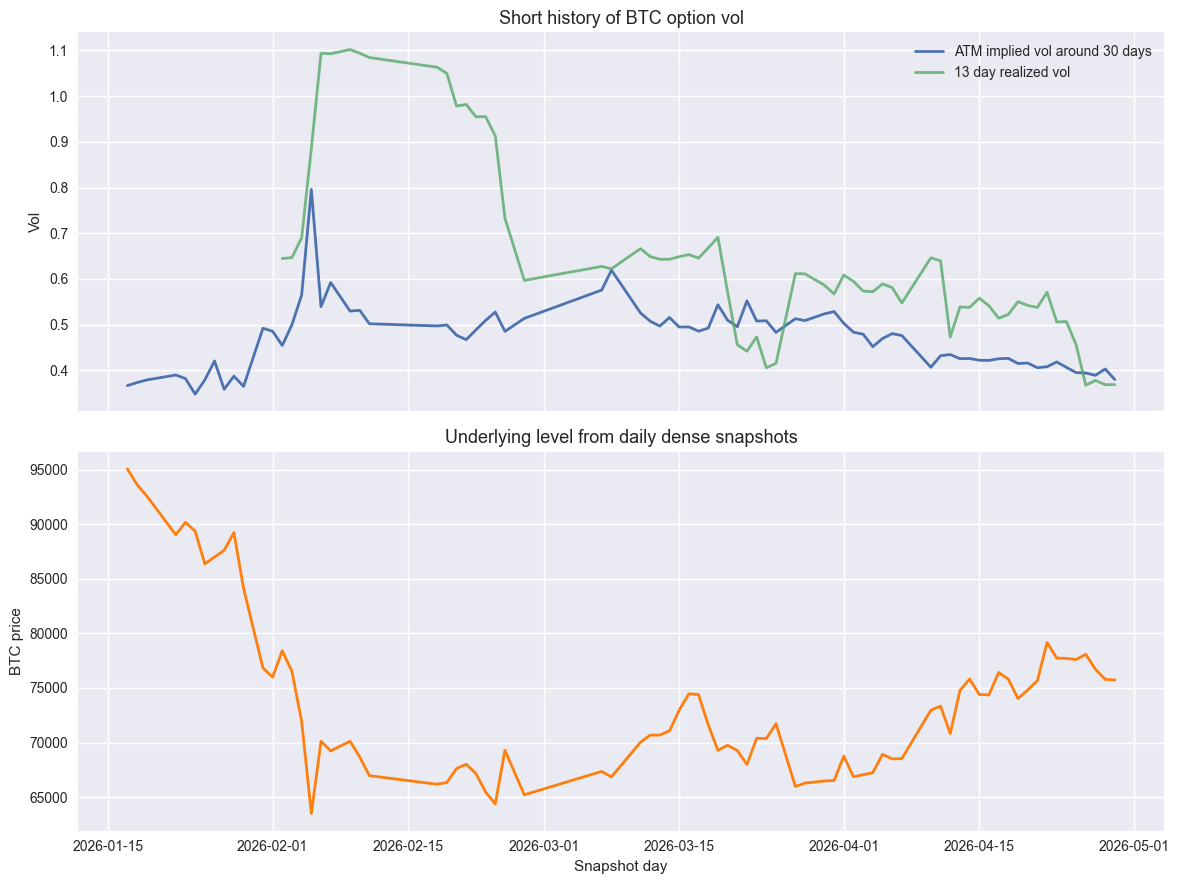

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].plot(
    history["snapshot_time"],
    history["iv_mid"],
    linewidth=2,
    label="ATM implied vol around 30 days",
)
axes[0].plot(
    history["snapshot_time"],
    history["realized_vol"],
    linewidth=2,
    alpha=0.8,
    label=f"{realized_vol_window} day realized vol",
)
axes[0].set_title("Short history of BTC option vol")
axes[0].set_ylabel("Vol")
axes[0].legend()

axes[1].plot(
    history["snapshot_time"],
    history["underlying_daily"],
    color="tab:orange",
    linewidth=2,
)
axes[1].set_title("Underlying level from daily dense snapshots")
axes[1].set_ylabel("BTC price")
axes[1].set_xlabel("Snapshot day")
plt.tight_layout()
plt.show()

The implied-realized spread and the underlying path matter for model selection: a structural model calibrated during a low-vol regime and tested in a vol spike will look worse than one calibrated closer to the test window. The walk-forward design partially controls for this, but checking the regime context is still the right first step before reading off any out-of-sample MAE numbers.

## Local volatility

Local vol is the minimal extension that makes the model internally consistent with the observed surface. Writing total implied variance as $w(k,T) = \sigma_{\text{imp}}^2 T$ with $k = \log(K/F)$, the Dupire formula pins $\sigma_{\text{loc}}$ uniquely:

$$\sigma_{\text{loc}}^2(k,T) = \frac{\partial_T w}{1 - \frac{k}{w}\partial_k w + \frac14\left(-\frac14 - \frac1w + \frac{k^2}{w^2}\right)(\partial_k w)^2 + \frac12 \partial_{kk} w}$$

The result is a diffusion that prices the current surface exactly and is free of calendar and butterfly arbitrage by construction. The cost is well-known: it requires a smooth, arbitrage-free input surface, it is purely static, and it has no mechanism for vol-of-vol dynamics — so it tends to underperform on forward smiles. Prices here are computed by Monte Carlo along the calibrated grid.

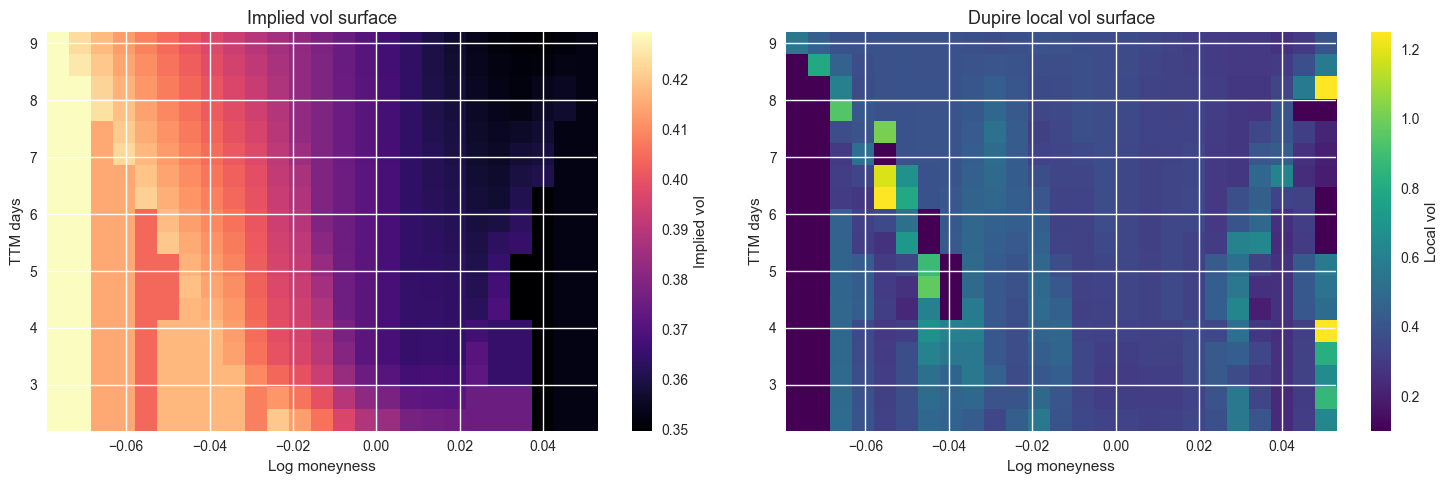

In [7]:
surface_input = enriched_snapshot.loc[
    enriched_snapshot["log_moneyness"].between(-0.18, 0.18)
    & enriched_snapshot["ttm"].between(2.0 / 365.0, 0.20)
] .copy()

surface_quotes = aggregate_surface_quotes(
    surface_input,
    ttm_decimals=5,
    moneyness_decimals=3,
)
surface_grid = build_surface_grid(surface_quotes, ttm_points=18, moneyness_points=25)
local_surface = dupire_local_vol(surface_grid, vol_floor=0.10, vol_cap=1.25)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

im0 = axes[0].imshow(
    surface_grid.iv_grid,
    aspect="auto",
    origin="lower",
    extent=[
        surface_grid.log_moneyness_grid.min(),
        surface_grid.log_moneyness_grid.max(),
        surface_grid.ttm_grid.min() * 365,
        surface_grid.ttm_grid.max() * 365,
    ],
    cmap="magma",
)
axes[0].set_title("Implied vol surface")
axes[0].set_xlabel("Log moneyness")
axes[0].set_ylabel("TTM days")
fig.colorbar(im0, ax=axes[0], label="Implied vol")

im1 = axes[1].imshow(
    local_surface.local_vol_grid,
    aspect="auto",
    origin="lower",
    extent=[
        local_surface.log_moneyness_grid.min(),
        local_surface.log_moneyness_grid.max(),
        local_surface.ttm_grid.min() * 365,
        local_surface.ttm_grid.max() * 365,
    ],
    cmap="viridis",
)
axes[1].set_title("Dupire local vol surface")
axes[1].set_xlabel("Log moneyness")
axes[1].set_ylabel("TTM days")
fig.colorbar(im1, ax=axes[1], label="Local vol")

plt.tight_layout()
plt.show()

In [8]:
sample_quotes = (
    surface_input.assign(
        score=surface_input["log_moneyness"].abs()
        + (surface_input["ttm_days"] - 30.0).abs() / 30.0
    )
    .sort_values(["score", "rel_spread"])
    .groupby("side")
    .head(2)
    .sort_values(["side", "ttm_days", "strike_price"])
    .reset_index(drop=True)
)

rows = []
for _, row in sample_quotes.iterrows():
    lv_price = price_local_vol_mc(
        spot=row["und_mid"],
        strike=row["strike_price"],
        ttm=row["ttm"],
        rate=RATE,
        option_type=row["side"],
        surface_grid=local_surface,
        n_paths=4000,
        n_steps=80,
        seed=7,
    )
    lv_iv = implied_volatility(
        price=lv_price,
        spot=row["und_mid"],
        strike=row["strike_price"],
        ttm=row["ttm"],
        rate=RATE,
        option_type=row["side"],
        initial_vol=row["iv_mid"],
    )
    rows.append(
        {
            "symbol": row["symbol"],
            "side": row["side"],
            "strike": row["strike_price"],
            "ttm_days": row["ttm_days"],
            "market_price": row["mid_price"],
            "market_iv": row["iv_mid"],
            "bs_price": row["bs_price"],
            "local_vol_price": lv_price,
            "local_vol_iv": float(np.atleast_1d(lv_iv)[0]),
            "price_gap_local_minus_market": lv_price - row["mid_price"],
        }
    )

comparison = pd.DataFrame(rows)
display(comparison.round(6))

,symbol,side,strike,ttm_days,market_price,market_iv,bs_price,local_vol_price,local_vol_iv,price_gap_local_minus_market
0,btc_usdc-8may26-78000-c,CALL,78000.0,9.194514,1230.0,0.359593,1230.0,1477.307940,0.411708,247.307940
1,btc_usdc-8may26-79000-c,CALL,79000.0,9.194514,852.5,0.351246,852.5,1207.163884,0.431049,354.663884
2,btc_usdc-8may26-75000-p,PUT,75000.0,9.194506,1090.0,0.386180,1090.0,2068.527730,0.600089,978.527730
3,btc_usdc-8may26-73000-p,PUT,73000.0,9.194514,585.0,0.404272,585.0,1407.684666,0.617319,822.684666


In-sample repricing against the calibration surface is a consistency check, not a performance test. The question of interest is whether local vol generalises when the surface shifts — which is what the walk-forward addresses.

## Walk-forward model comparison

The test is simple and strict: hyperparameters are selected on training days only, the model is refit once per day on the trailing five-day window, and pricing error is recorded on the next unseen day. No lookahead, no pooling across train and test. The winner is the model that minimises out-of-sample MAE over 23 test days, not the one with the best in-sample surface fit.

The comparison includes both pure market-fitting models (flat vol, term structure, IV surface) and structural models (local vol, Merton, Heston, Bates). Structural richness is hypothesised to improve out-of-sample performance when the surface is noisy or sparse — the question is whether the calibration budget available in a daily refit is sufficient to make that advantage concrete.

### The extension models

#### Flat vol Black-Scholes

The baseline. I estimate a single constant implied volatility $\hat\sigma$ from the training cross-section (median or mean across all liquid quotes) and price every test contract with Black-Scholes at that one number. It has no free structure at all. If nothing else beats it, that is a data problem, not a modelling result.

#### ATM term structure Black-Scholes

Allows $\sigma$ to vary by maturity but not by strike. I estimate $\hat\sigma(T)$ by averaging only the near-ATM quotes within a moneyness band $|k| < \epsilon$ for each expiry bucket. The result is a piecewise flat smile: no skew, but the level can shift with tenor. In practice this is often enough to absorb the steepest part of the term structure premium.

#### IV surface Black-Scholes

Goes one step further by interpolating a full $\hat\sigma(k, T)$ surface from market quotes and then reading off the implied vol for each test contract at its own $(k, T)$ coordinate. This is a pure market-fit model with no structural view on how vol is generated. Its out-of-sample performance is the hardest benchmark for any structural model to beat.

#### Local volatility (Dupire)

Converts the observed implied vol surface into a state-dependent diffusion

$$dS_t = r S_t \, dt + \sigma_{\text{loc}}(t, S_t) \, S_t \, dW_t$$

where $\sigma_{\text{loc}}$ is pinned to market prices by the Dupire formula applied to total implied variance $w(k,T) = \sigma_{\text{imp}}^2 T$. Unlike the surface-BS model, local vol is internally arbitrage-free and can be propagated forward in time. Prices are computed by Monte Carlo simulation along the calibrated diffusion.

#### Merton jump diffusion

Adds Poisson-distributed jumps to the geometric Brownian motion

$$dS_t = (r - \lambda \bar\mu) S_t \, dt + \sigma S_t \, dW_t + (e^J - 1) S_t \, dN_t$$

where $N_t$ is a Poisson process with intensity $\lambda$, jump log-size $J \sim \mathcal{N}(\mu_J, \delta^2)$, and $\bar\mu = e^{\mu_J + \frac12\delta^2} - 1$. The closed-form price is a Poisson-weighted sum of Black-Scholes terms

$$C_{\text{Merton}} = \sum_{n=0}^{\infty} \frac{e^{-\lambda' T} (\lambda' T)^n}{n!} C_{\text{BS}}\!\left(\sigma_n\right)$$

with $\lambda' = \lambda e^{\mu_J + \frac12\delta^2}$ and $\sigma_n^2 = \sigma^2 + n\delta^2/T$. It is fast to evaluate and can produce skew, but the volatility surface it generates is symmetric around ATM and relatively inflexible.

#### Heston

Models the instantaneous variance $V_t = \sigma_t^2$ as a mean-reverting CIR process correlated with spot

$$dS_t = r S_t \, dt + \sqrt{V_t} \, S_t \, dW_t^S$$

$$dV_t = \kappa(\theta - V_t) \, dt + \xi \sqrt{V_t} \, dW_t^V, \qquad d\langle W^S, W^V \rangle_t = \rho \, dt$$

The five parameters are $(\kappa, \theta, \xi, \rho, V_0)$: mean-reversion speed, long-run variance, vol-of-vol, spot-vol correlation, and initial variance. Option prices are computed by characteristic-function integration (Gil-Pelaez inversion). The negative $\rho$ parameter is what generates left skew: when spot falls, variance rises, which is exactly the leverage effect observed in equity and to a lesser degree in crypto.

#### Bates

Extends Heston by superimposing Merton-style compound Poisson jumps on the spot dynamics

$$dS_t = (r - \lambda \bar\mu) S_t \, dt + \sqrt{V_t} \, S_t \, dW_t^S + (e^J - 1) S_t \, dN_t$$

with $V_t$ still following the Heston CIR dynamics. The characteristic function gains three jump parameters $(\lambda, \mu_J, \delta)$ on top of the five Heston parameters. Bates can fit both the persistent skew that Heston captures and the fat short-dated wings that jumps produce. It is the most flexible model in the comparison, but that flexibility comes at a calibration cost: eight parameters calibrated to a noisy intraday surface is a hard optimisation problem.

In [9]:
TRAIN_WINDOW_DAYS = 5
TRAIN_FRACTION = 0.70

MODEL_GRIDS = {
    "flat_bs": [
        {"estimator": "median"},
        {"estimator": "mean"},
    ],
    "term_bs": [
        {"atm_band": 0.02, "ttm_round_days": 0.5},
        {"atm_band": 0.04, "ttm_round_days": 1.0},
        {"atm_band": 0.06, "ttm_round_days": 1.0},
    ],
    "surface_bs": [
        {"ttm_decimals": 5, "moneyness_decimals": 3, "ttm_points": 12, "moneyness_points": 17},
        {"ttm_decimals": 5, "moneyness_decimals": 3, "ttm_points": 18, "moneyness_points": 25},
    ],
    "local_vol": [
        {
            "ttm_decimals": 5,
            "moneyness_decimals": 3,
            "ttm_points": 12,
            "moneyness_points": 17,
            "vol_floor": 0.08,
            "vol_cap": 1.10,
            "n_paths": 800,
            "n_steps": 30,
        },
        {
            "ttm_decimals": 5,
            "moneyness_decimals": 3,
            "ttm_points": 18,
            "moneyness_points": 25,
            "vol_floor": 0.10,
            "vol_cap": 1.25,
            "n_paths": 800,
            "n_steps": 30,
        },
    ],
    "merton_jump": [
        {"jump_intensity": 0.25, "jump_mean": -0.04, "jump_vol": 0.10, "atm_band": 0.03, "estimator": "median"},
        {"jump_intensity": 0.50, "jump_mean": -0.06, "jump_vol": 0.12, "atm_band": 0.03, "estimator": "median"},
    ],
    "heston": [
        {
            "initial_guess": (1.5, 0.04, 0.40, -0.65, 0.05),
            "bounds": ((0.2, 6.0), (0.01, 0.50), (0.05, 1.50), (-0.95, -0.05), (0.01, 0.50)),
            "integration_limit": 60.0,
            "integration_points": 96,
            "maxiter": 20,
            "max_quotes": 80,
        },
        {
            "initial_guess": (2.0, 0.05, 0.60, -0.75, 0.06),
            "bounds": ((0.3, 8.0), (0.01, 0.80), (0.10, 2.00), (-0.98, -0.05), (0.01, 0.80)),
            "integration_limit": 80.0,
            "integration_points": 128,
            "maxiter": 25,
            "max_quotes": 100,
        },
    ],
    "bates": [
        {
            "initial_guess": (1.5, 0.04, 0.45, -0.65, 0.05, 0.40, -0.05, 0.12),
            "bounds": ((0.2, 6.0), (0.01, 0.50), (0.05, 1.50), (-0.95, -0.05), (0.01, 0.50), (0.05, 1.50), (-0.30, 0.05), (0.03, 0.30)),
            "integration_limit": 60.0,
            "integration_points": 96,
            "maxiter": 20,
            "max_quotes": 80,
        }
    ],
}

evaluation_panel = daily_snapshot_panel.loc[
    daily_snapshot_panel["log_moneyness"].between(-0.18, 0.18)
] .copy()

walk_forward_results = walk_forward_model_grid_search(
    evaluation_panel,
    model_grids=MODEL_GRIDS,
    rate=RATE,
    train_window_days=TRAIN_WINDOW_DAYS,
    train_fraction=TRAIN_FRACTION,
    seed=7,
)

validation_grid = walk_forward_results["validation_grid"].copy()
best_configs = walk_forward_results["best_configs"].copy()
test_daily = walk_forward_results["test_daily"].copy()
test_summary = walk_forward_results["test_summary"].copy()

family_labels = {
    "flat_bs": "Flat vol BS",
    "term_bs": "ATM term BS",
    "surface_bs": "IV surface BS",
    "local_vol": "Local vol",
    "merton_jump": "Merton jump",
    "heston": "Heston",
    "bates": "Bates",
}

for frame in [validation_grid, best_configs, test_daily, test_summary]:
    frame["model"] = frame["family"].map(family_labels)

test_daily["test_time"] = pd.to_datetime(test_daily["day"], unit="D", origin="unix")

print(f"Walk-forward days available: {evaluation_panel['snapshot_day'].nunique()}")
print(f"Training days in grid search: {len(walk_forward_results['train_days'])}")
print(f"Test days: {len(walk_forward_results['test_days'])}")
print(f"Daily refit window: {TRAIN_WINDOW_DAYS} days")

display(
    validation_grid[
        [
            "model",
            "config",
            "validation_days",
            "validation_quotes",
            "validation_mae",
            "validation_rmse",
        ]
    ].round(6)
 )

display(
    test_summary[
        [
            "model",
            "test_days",
            "test_quotes",
            "test_mae",
            "test_rmse",
            "test_bias",
        ]
    ].round(6)
 )

display(best_configs[["model", "config", "validation_mae"]])

Walk-forward days available: 79
Training days in grid search: 56
Test days: 23
Daily refit window: 5 days


,model,config,validation_days,validation_quotes,validation_mae,validation_rmse
0,IV surface BS,"{'ttm_decimals': 5, 'moneyness_decimals': 3, '...",51,8946,154.895716,204.930554
1,IV surface BS,"{'ttm_decimals': 5, 'moneyness_decimals': 3, '...",51,8946,159.018999,211.180630
2,ATM term BS,"{'atm_band': 0.06, 'ttm_round_days': 1.0}",51,8946,183.024867,239.343986
3,ATM term BS,"{'atm_band': 0.04, 'ttm_round_days': 1.0}",51,8946,184.814885,241.570569
4,ATM term BS,"{'atm_band': 0.02, 'ttm_round_days': 0.5}",51,8946,185.056795,239.698344
5,Merton jump,"{'jump_intensity': 0.25, 'jump_mean': -0.04, '...",51,8946,196.639206,258.930197
6,Flat vol BS,{'estimator': 'median'},51,8946,196.819786,259.951759
7,Merton jump,"{'jump_intensity': 0.5, 'jump_mean': -0.06, 'j...",51,8946,199.488021,262.971900
8,Flat vol BS,{'estimator': 'mean'},51,8946,218.731663,293.907306
9,Local vol,"{'ttm_decimals': 5, 'moneyness_decimals': 3, '...",51,8946,514.781031,2936.901727


,model,test_days,test_quotes,test_mae,test_rmse,test_bias
0,IV surface BS,23,5136,94.511979,127.647975,36.444766
1,ATM term BS,23,5136,121.827709,155.570186,11.490310
2,Merton jump,23,5136,129.809931,170.765616,40.476577
3,Flat vol BS,23,5136,129.876423,169.301728,42.974073
4,Local vol,23,5136,212.797329,375.151789,50.297280
5,Heston,23,5136,722.667671,944.800582,-719.246224
6,Bates,23,5136,829.053779,1023.746517,-827.374204


,model,config,validation_mae
0,IV surface BS,"{'ttm_decimals': 5, 'moneyness_decimals': 3, '...",154.895716
1,ATM term BS,"{'atm_band': 0.06, 'ttm_round_days': 1.0}",183.024867
2,Merton jump,"{'jump_intensity': 0.25, 'jump_mean': -0.04, '...",196.639206
3,Flat vol BS,{'estimator': 'median'},196.819786
4,Local vol,"{'ttm_decimals': 5, 'moneyness_decimals': 3, '...",514.781031
5,Heston,"{'initial_guess': (2.0, 0.05, 0.6, -0.75, 0.06...",1003.678116
6,Bates,"{'initial_guess': (1.5, 0.04, 0.45, -0.65, 0.0...",1101.501816


Validation MAE selects the configuration; test MAE is the number that matters. A model that requires a different configuration each day to stay competitive is not a stable model — that signal is visible in the per-day error lines on the right panel.

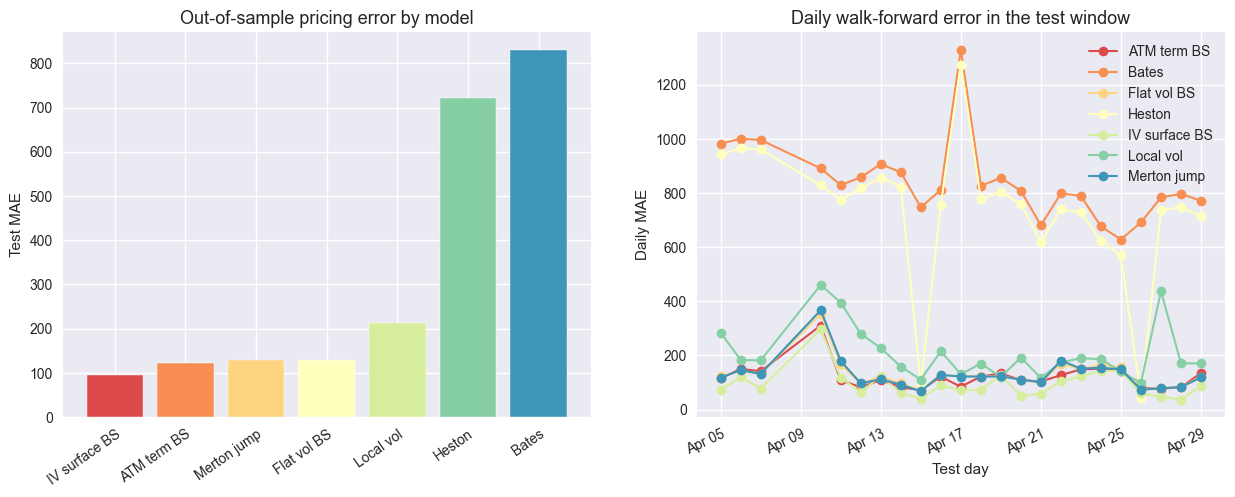

<Figure size 1100x600 with 0 Axes>

In [10]:
plot_summary = test_summary.sort_values("test_mae").copy()
daily_plot = test_daily.sort_values(["model", "test_time"]).copy()
palette = sns.color_palette("Spectral", n_colors=len(plot_summary))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].bar(plot_summary["model"], plot_summary["test_mae"], color=palette)
axes[0].set_title("Out-of-sample pricing error by model")
axes[0].set_ylabel("Test MAE")
axes[0].set_xlabel("")
plt.setp(axes[0].get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor")

for color, (model_name, model_frame) in zip(palette, daily_plot.groupby("model")):
    axes[1].plot(
        model_frame["test_time"],
        model_frame["mae"],
        marker="o",
        linewidth=1.5,
        color=color,
        label=model_name,
    )

axes[1].set_title("Daily walk-forward error in the test window")
axes[1].set_ylabel("Daily MAE")
axes[1].set_xlabel("Test day")
plt.setp(axes[1].get_xticklabels(), rotation=25, ha="right", rotation_mode="anchor")
axes[1].xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b %d"))
axes[1].legend(loc="upper right", framealpha=0.85, ncol=1)

plt.show()
plt.tight_layout()

In [11]:
best_model_row = test_summary.sort_values("test_mae").iloc[0]
worst_model_row = test_summary.sort_values("test_mae").iloc[-1]

print(
    f"Best out-of-sample model on the full daily sample: {best_model_row['model']} "
    f"with test MAE {best_model_row['test_mae']:.2f}."
)
print(
    f"Worst out-of-sample model on the full daily sample: {worst_model_row['model']} "
    f"with test MAE {worst_model_row['test_mae']:.2f}."
)

Best out-of-sample model on the full daily sample: IV surface BS with test MAE 94.51.
Worst out-of-sample model on the full daily sample: Bates with test MAE 829.05.


In [12]:
fig.savefig("imgs/OptionPricingWalkForward.png", dpi=150, bbox_inches="tight")

## Conclusion

The IV surface model wins the walk-forward, with a test MAE around 94.5 over 23 test days. ATM term structure is the closest alternative. Flat-vol BS and Merton sit in the same tier. Local vol is unstable. Heston and Bates are the worst performers, with Bates the weakest model in the set.

The result is not surprising given the calibration design. Structural models with five to eight free parameters, fitted to a single dense intraday snapshot, face a difficult optimisation problem: the surface is noisy, the optimiser has limited budget (20–25 iterations), and the model extrapolates to test strikes and expiries that were not well-represented in the training cross-section. The IV surface model has none of those problems because it makes no structural assumptions and interpolates directly from the training data.

The appropriate conclusion is not that Heston and Bates are inferior models. It is that they require a more careful calibration design to compete: a richer loss function, multi-day pooling across parameter estimates, or a warmer start using the previous day's solution. Under a tighter optimisation regime the structural advantage of stochastic vol — better forward-smile dynamics, more stable hedges, a physically interpretable vol process — has room to materialise. That is the natural next experiment.